[![Fixel Algorithms](https://i.imgur.com/AqKHVZ0.png)](https://fixelalgorithms.gitlab.io)

# AI Program

## Scientific Python - SciPy

> Notebook by:
> - Royi Avital RoyiAvital@fixelalgorithms.com

## Revision History

| Version | Date       | User        |Content / Changes                                                   |
|---------|------------|-------------|--------------------------------------------------------------------|
| 0.2.000 | 26/03/2026 | Royi Avital | Added interpolation task                                           |
| 0.1.002 | 27/03/2026 | Royi Avital | Added resources on Numba for vectorization of a scalar function    |
| 0.1.001 | 25/02/2024 | Royi Avital | Added assertion to verify the sign at the edges of the segment     |
| 0.1.001 | 25/02/2024 | Royi Avital | Added horizontal line at $0$ to the function                       |
| 0.1.000 | 16/02/2024 | Royi Avital | First version                                                      |

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FixelAlgorithmsTeam/FixelCourses/blob/master/AIProgram/2024_02/0022SciPy.ipynb)

In [40]:
# Import Packages

# General Tools
import numpy as np
import scipy as sp
import pandas as pd

from numba import jit, njit

# Miscellaneous
from platform import python_version
import random

# Typing
from typing import Callable, List, Tuple, Union
from numpy.typing import NDArray

# Visualization
import matplotlib.pyplot as plt

# Jupyter
from IPython import get_ipython

## Notations

* <font color='red'>(**?**)</font> Question to answer interactively.
* <font color='blue'>(**!**)</font> Simple task to add code for the notebook.
* <font color='green'>(**@**)</font> Optional / Extra self practice.
* <font color='brown'>(**#**)</font> Note / Useful resource / Food for thought.

Code Notations:

```python
someVar    = 2; #<! Notation for a variable
vVector    = np.random.rand(4) #<! Notation for 1D array
mMatrix    = np.random.rand(4, 3) #<! Notation for 2D array
tTensor    = np.random.rand(4, 3, 2, 3) #<! Notation for nD array (Tensor)
tuTuple    = (1, 2, 3) #<! Notation for a tuple
lList      = [1, 2, 3] #<! Notation for a list
dDict      = {1: 3, 2: 2, 3: 1} #<! Notation for a dictionary
oObj       = MyClass() #<! Notation for an object
dfData     = pd.DataFrame() #<! Notation for a data frame
dsData     = pd.Series() #<! Notation for a series
hObj       = plt.Axes() #<! Notation for an object / handler / function handler
```

### Code Exercise

 - Single line fill

```python
valToFill = ???
```

 - Multi Line to Fill (At least one)

```python
# You need to start writing
?????
```

 - Section to Fill

```python
#===========================Fill This===========================#
# 1. Explanation about what to do.
# !! Remarks to follow / take under consideration.
mX = ???

?????
#===============================================================#
```

In [2]:
# Configuration
# %matplotlib inline

seedNum = 512
np.random.seed(seedNum)
random.seed(seedNum)

# Matplotlib default color palette
lMatPltLibclr = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
# sns.set_theme() #>! Apply SeaBorn theme

runInGoogleColab = 'google.colab' in str(get_ipython())

In [3]:
# Constants

FIG_SIZE_DEF    = (8, 8)
ELM_SIZE_DEF    = 50
CLASS_COLOR     = ('b', 'r')
EDGE_COLOR      = 'k'
MARKER_SIZE_DEF = 10
LINE_WIDTH_DEF  = 2

In [4]:
# Course Packages


In [5]:
# General Auxiliary Functions

@njit
def Sign( valX: Union[int, float] ) -> int:
    # Read about Python's missing `sign()` function: https://stackoverflow.com/questions/1986152
    # Some implementation notes: https://note.nkmk.me/en/python-sign-copysign

    return (valX > 0) - (valX < 0)

## SciPy

SciPy is the _scientific_ / _technical_ _computing_ in the _Python_ eco system.  
It is composed of a different sub packages and strongly relies on _NumPy_.

This _notebook_ exercises some SciPy's capabilities.  

* <font color='brown'>(**#**)</font> [SciPy User Guide](https://docs.scipy.org/doc/scipy/tutorial/index.html).
* <font color='brown'>(**#**)</font> [For performance measurement the package [`timeit`](https://docs.python.org/3/library/timeit.html) or the `%timeit` magic will be used].
* <font color='brown'>(**#**)</font> For visualization the package [Matplotlib](https://github.com/matplotlib/matplotlib) will be used.
* <font color='brown'>(**#**)</font> For acceleration the package [Numba](https://github.com/numba/numba) will be used.

## Finding a Root of a Function

The task of finding the root of a function $f \left( x \right)$ means finding $\hat{x}$ such that $f \left( \hat{x} \right) = 0$.

* <font color='brown'>(**#**)</font> Given an algorithm to find a root of a function one can create an optimization algorithm by applying it on $f' \left( x \right)$ given it is smooth.

In this section the function is given by $f \left( x \right) = 1 - 3 {e}^{-x}$.

* <font color='brown'>(**#**)</font> SciPy has several _root finding_ functions in its _Optimization_ sub package: [SciPy's Root Finding](https://docs.scipy.org/doc/scipy/reference/optimize.html#root-finding).

In [6]:
# Parameters

tuDataGrid = (0, 5, 50)

In [7]:
# Model Function

@njit
def F( vX: NDArray ) -> NDArray:

    return 1 - 3 * np.exp(-vX)

* <font color='brown'>(**#**)</font> The function above matches teh case for using Numba's `@vectorize` option.  
  See [Numba - Creating NumPy Universal Functions](https://numba.readthedocs.io/en/stable/user/vectorize.html).
* <font color='brown'>(**#**)</font> One can improve some code run time by using `fastmath` option in Numba.  
  See [Numba - Performance Tips](https://numba.readthedocs.io/en/stable/user/performance-tips.html).

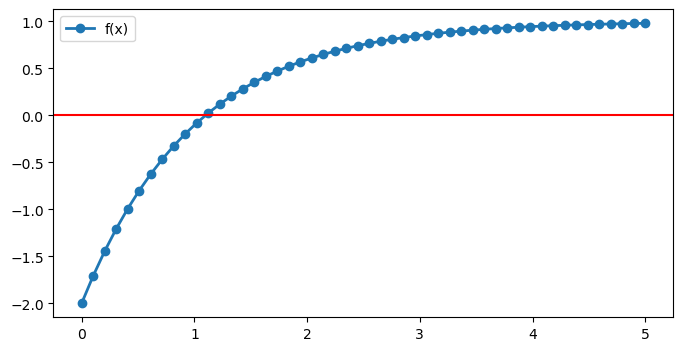

In [8]:
# Generate / Load  Data 

vX = np.linspace(tuDataGrid[0], tuDataGrid[1], tuDataGrid[2])
vY = F(vX)

# Display Data

hF, hA = plt.subplots(figsize = (8, 4))
hLine = hA.plot(vX, vY, lw = LINE_WIDTH_DEF, label = 'f(x)')
hLine[0].set_marker('o')
hA.axhline(y = 0, color = 'r')

hA.legend();

### Bisection Method  

One of the simplest methods for root finding is the [_Bisection Method_](https://en.wikipedia.org/wiki/Bisection_method).

<!-- ![](https://upload.wikimedia.org/wikipedia/commons/8/8c/Bisection_method.svg) -->

<div>
<img src="https://upload.wikimedia.org/wikipedia/commons/8/8c/Bisection_method.svg" height = "400"/>
</div>

This section implements the method as described in the Wikipedia article.

* <font color='brown'>(**#**)</font> The _bisection_ method solves the cases the function has a segment where its sign on each side is opposite.  
  For instance, it can't find the zero of a parabolic function with the minimum / maximum value of $0$.
* <font color='brown'>(**#**)</font> SciPy's implement much more efficient methods such as the _Brent’s method_ ([`brentq()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.brentq.html#scipy.optimize.brentq)).


In [19]:
# Bisection Method

#===========================Fill This===========================#
# 1. Implement the Bisection Method as given in Wikipedia.
# !! Try minimizing the use of `if` inside the main loop.
# !! You may use the `Sign()` function defined above.

@njit
def BisectionMethodRoot( hF: Callable, valA: float, valB: float, /, numItr: int = 1000, ε: float = 1e-6 ) -> float:
    """
    Finds a root of `hF` in the range (valA, valB).  
    The function is assumed to be continuous.  
    It is assumed that `valB > valA`.
    The output is within `ε` radius of the root location.
    Input:
        hF      - Callable, The function to find a root of.
        valA    - The left boundary for the search segment.
        valB    - The right boundary for the search segment.
        numItr  - Maximum number of iterations.
        ε       - The maximum distance between the output and the actual root.
    Output:
        valC    - The argument of the function such that `|valC - valX| < ε` where `hF(valX) = 0`.
    """
    for ii in range(numItr):
        valC = 0.5 * (valA + valB)
        if ((valB - valA) <= ε)  and (Sign(hF(valA)) != Sign(hF(valB))):
            return valC

        elif Sign(hF(valA)) != Sign(hF(valC)):
            valB = valC

        else:
            valA = valC

    return valC

#===============================================================#

In [20]:
# Verify the Implementation
# This section uses SciPy's `bisect` function.
# It will compare the implementation to SciPy's implementation.

valA = float(tuDataGrid[0])
valB = float(tuDataGrid[1])
ε    = 1e-6

# Values
valXRef = sp.optimize.bisect(F, valA, valB, xtol = ε)
valX = BisectionMethodRoot(F, valA, valB, ε = ε)

# Timing (See https://stackoverflow.com/questions/17310752)
runTimeSciPy = %timeit -o sp.optimize.bisect(F, valA, valB, xtol = ε)
runTimeBiSec = %timeit -o BisectionMethodRoot(F, valA, valB, ε = ε)

print(f'The root by SciPy           : {valXRef}')
print(f'The root by implementation  : {valX}')
print(f'The implementation is verified: {abs(valXRef - valX) < (ε / 2)}')

relativeRun     = runTimeSciPy.best / runTimeBiSec.best
relativeRun     = relativeRun if relativeRun >= 1.0 else 1 / relativeRun
relativeRunStr  = 'faster' if runTimeBiSec.best < runTimeSciPy.best else 'slower'

print(f'The implementation is {relativeRun: 0.2f} times {relativeRunStr} than SciPy\'s implementation')

20.5 μs ± 400 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
4.25 μs ± 40 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
The root by SciPy           : 1.0986119508743286
The root by implementation  : 1.0986122488975525
The implementation is verified: True
The implementation is  4.80 times faster than SciPy's implementation


* <font color='blue'>(**!**)</font> Try removing the `njit` decorator and measure performance.

## Integrating a Function

This section calculates the integral over a function in a closed segment (_Definite Integral_).  

SciPy has 2 main different methods of integration:

1. Given a Function Object  
   Given a function to calculate the value at an arbitrary point.
2. Given a Set of Data Samples  
   If the function is not known yet sampled.

This section compares 2 methods: 

 - [`quad()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html#scipy.integrate.quad) - Based on a function.
 - [`simpson()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.simpson.html#scipy.integrate.simpson) - Based on samples.

The function which will be used is: $f \left( x \right) = 1 + {e}^{-\frac{x}{2}} + \sin \left( 3 x \right)$.

In [21]:
# Parameters

tuDataGrid = (0, 5, 50)
valA = 1.0
valB = 4.0

In [22]:
# Model Function

@njit
def F( vX: NDArray ) -> NDArray:

    return 1 + np.exp(-vX / 2) + np.sin(3 * vX)

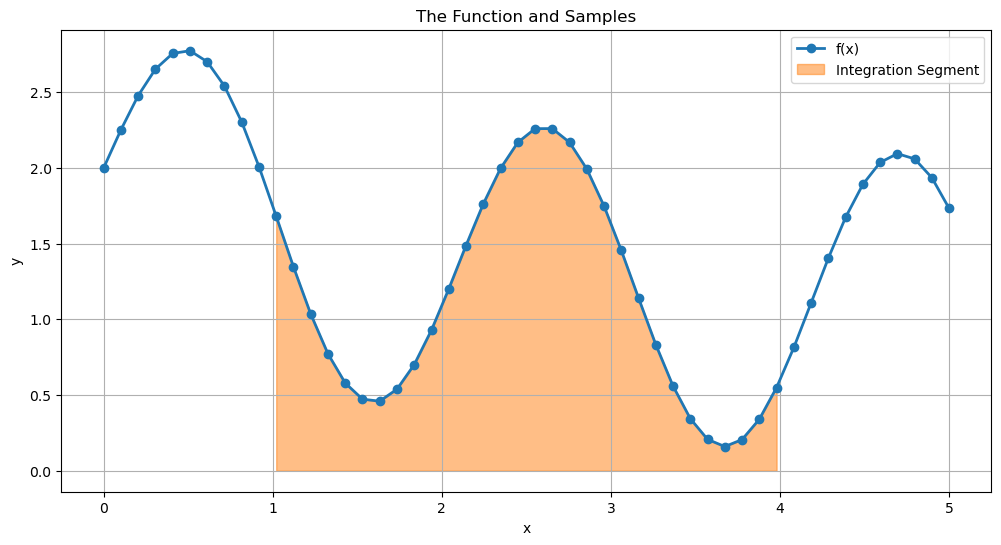

In [23]:
# Generate / Load  Data 

vX = np.linspace(tuDataGrid[0], tuDataGrid[1], tuDataGrid[2])
vY = F(vX)

# Display Data

hF, hA = plt.subplots(figsize = (12, 6))
hLine = hA.plot(vX, vY, lw = LINE_WIDTH_DEF, label = 'f(x)')
hLine[0].set_marker('o')
hA.fill_between(x = vX, y1 = vY, where = np.logical_and(vX >= valA, vX <= valB), color = lMatPltLibclr[1], alpha = 0.5, label = 'Integration Segment')
hA.set_title('The Function and Samples')
hA.set_xlabel('x')
hA.set_ylabel('y')
hA.grid(True)

hA.legend();

In [29]:
# Integration of the Function
# This section calculates the integration of the function by `quad()`.

#===========================Fill This===========================#
# 1. Calculate the integral of the function in the segment (valA, valB).
# !! Use `quad()` for the integration.
fun = lambda x: F(x)
intValFunction, *_ = sp.integrate.quad(fun, valA, valB)
intValFunction
#===============================================================#

3.3311086011743956

In [35]:
# Integration of the Samples
# This section calculates the integration of the function by `simpson()`.
# One may read on the method in https://en.wikipedia.org/wiki/Simpson%27s_rule.

#===========================Fill This===========================#
# 1. Calculate the integral of the samples in the segment (valA, valB).
# !! Use `simpson()` for the integration.

x = np.linspace(1, 4, 41)
y = F(x)
intValSamples = sp.integrate.simpson(y, x=x)
intValSamples
#===============================================================#

np.float64(3.3310998551838207)

In [36]:
print(f'The integration by the **function** : {intValFunction}')
print(f'The integration by the **samples**  : {intValSamples}')

The integration by the **function** : 3.3311086011743956
The integration by the **samples**  : 3.3310998551838207


* <font color='red'>(**?**)</font> Which method is more accurate?
* <font color='blue'>(**!**)</font> Measure the run time of each method.
* <font color='red'>(**?**)</font> If we're given samples yet only can use `quad()`, what should we do?

## Interpolate a Function

This section wraps samples into a callable function using interpolation.  

Namely, given a set of samples $\left\{ \left( {x}_{i}, {y}_{i} \right) \right\}_{i = 1}^{N}$ wrap into an interpolation based function:

$$
g \left ( x \right) = \begin{cases}
{y}_{i} & \text{if} \; x = {x}_{i} \\
y & \text{if}\; x \neq {x}_{i} 
\end{cases}
$$

Where $y$ is generated by interpolation model.  
Once the function is defined it will be used to calculate the integral using `quad()` and compared to using `simpson()`.

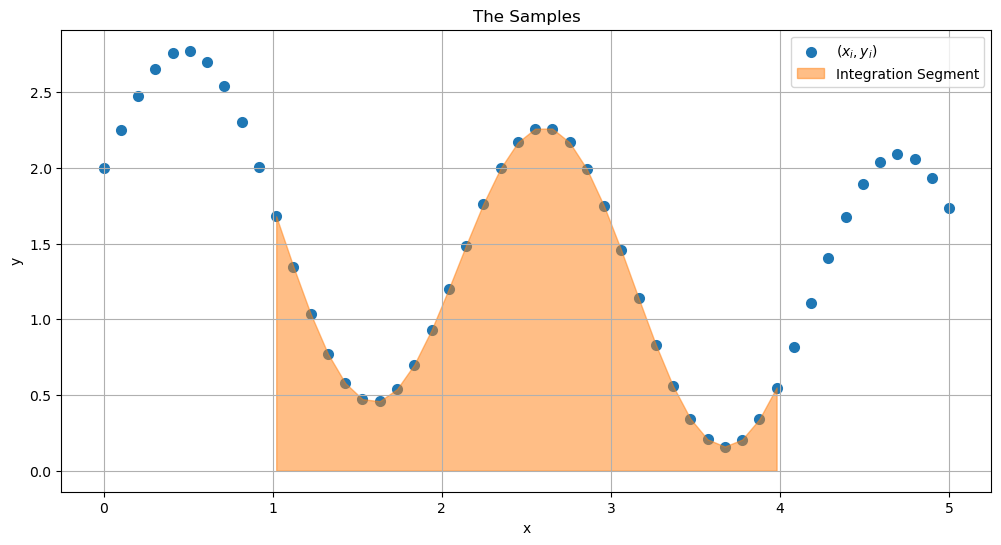

In [38]:
# Generate / Load  Data 

vX = np.linspace(tuDataGrid[0], tuDataGrid[1], tuDataGrid[2])
vY = F(vX)

# Display Data

hF, hA = plt.subplots(figsize = (12, 6))
hLine = hA.scatter(vX, vY, lw = LINE_WIDTH_DEF, label = r'$\left (x_i, y_i \right)$')
hA.fill_between(x = vX, y1 = vY, where = np.logical_and(vX >= valA, vX <= valB), color = lMatPltLibclr[1], alpha = 0.5, label = 'Integration Segment')
hA.set_title('The Samples')
hA.set_xlabel('x')
hA.set_ylabel('y')
hA.grid(True)

hA.legend();

In [41]:
# Build Interpolation Model

#===========================Fill This===========================#
# 1. Use the samples to build the interpolation model.
# !! Use `PchipInterpolator` class for the model.
from scipy.interpolate import PchipInterpolator
hG = PchipInterpolator(vX, vY)

#===============================================================#

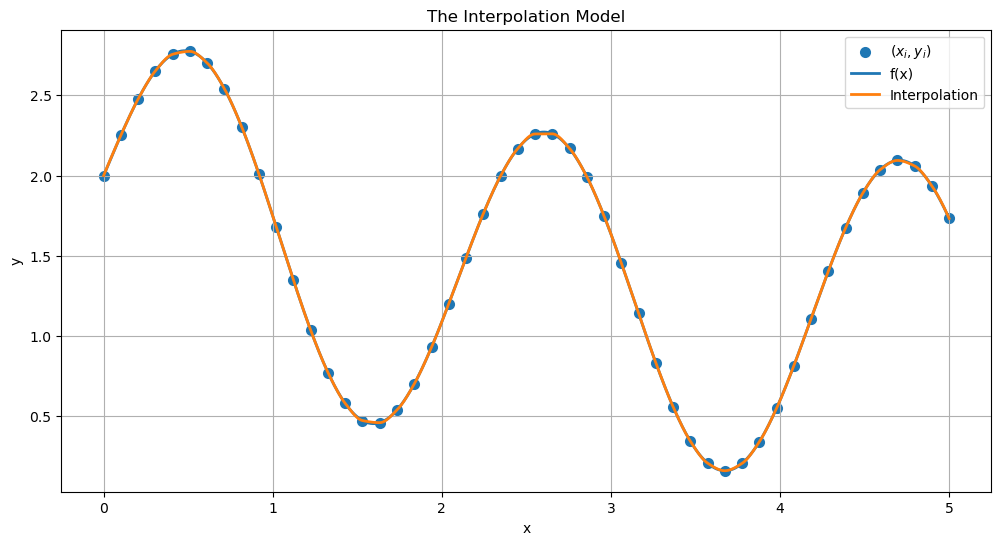

In [42]:
# Display the Interpolation Model

vXX  = np.linspace(tuDataGrid[0], tuDataGrid[1], 5001)
vYY  = F(vXX)
vYYi = hG(vXX)

hF, hA = plt.subplots(figsize = (12, 6))
hA.scatter(vX, vY, lw = LINE_WIDTH_DEF, label = r'$\left (x_i, y_i \right)$')
hA.plot(vXX, vYY, lw = LINE_WIDTH_DEF, label = 'f(x)')
hA.plot(vXX, vYYi, lw = LINE_WIDTH_DEF, label = 'Interpolation')
hA.set_title('The Interpolation Model')
hA.set_xlabel('x')
hA.set_ylabel('y')
hA.grid(True)
hA.legend();

In [43]:
# Compare Integration by the Interpolation Model

vS = np.logical_and(vX >= valA, vX <= valB) #<! Segment

print(f'The integration by the **function**      : {sp.integrate.quad(F, valA, valB)[0]}')
print(f'The integration by the **interpolation** : {sp.integrate.quad(hG, valA, valB, epsabs = 1e-6, limit = 200)[0]}')
print(f'The integration by the **samples**       : {sp.integrate.simpson(vY[vS], x = vX[vS])}')

The integration by the **function**      : 3.3311086011743956
The integration by the **interpolation** : 3.3312005885597618
The integration by the **samples**       : 3.2843093923125415
